In [13]:
import numpy as np
import pandas as pd 
import scipy as sp
import scipy.signal as spg
import cmath
import scipy.constants as const
import matplotlib.pyplot as plt
import sys
sys.path.append('/Users/leayamashiro/whispering_gallery_MAIN/calibrated/analysis')
import useful_functions as uf


In [18]:
uf.find_plot_Q_peaks?

Signature: uf.find_plot_Q_peaks(Q_freq_data, n_peaks)
Docstring: <no docstring>
File:      ~/whispering_gallery_MAIN/calibrated/new_Q/useful_functions.py
Type:      function

In [14]:
alumina_zotefoam = uf.fix_csv('EigenRadiusSweep_Al&ZotefoamContactModel_2.5to5.5GHz.csv', '/Users/leayamashiro/whispering_gallery_MAIN/calibrated/new_Q/Q_data/')
alumina_zotefoam

,% r_zotefoam (m),search_freq (Hz),Eigenfrequency (GHz),Frequency (GHz),Quality factor (1)
0,0.019056,2.500000e+09,2.300990+0.120102j,2.300990,9.579283
1,0.019056,2.500000e+09,2.301470+0.118395j,2.301470,9.719449
2,0.019056,2.500000e+09,2.302208+0.000443j,2.302208,2598.764480
3,0.019056,2.500000e+09,2.302459+0.000443j,2.302459,2595.928723
4,0.019056,2.500000e+09,2.315833+0.090437j,2.315833,12.803622
...,...,...,...,...,...
8395,0.076225,5.500000e+09,5.607012+0.007926j,5.607012,353.721377
8396,0.076225,5.500000e+09,5.614071+0.016858j,5.614071,166.510894
8397,0.076225,5.500000e+09,5.615189+0.009108j,5.615189,308.255028
8398,0.076225,5.500000e+09,5.616563+0.041967j,5.616563,66.915974


In [15]:
quarter_R = alumina_zotefoam[alumina_zotefoam['% r_zotefoam (m)'].round(6)==0.019056]
third_R = alumina_zotefoam[alumina_zotefoam['% r_zotefoam (m)'].round(6)==0.025408]
half_R = alumina_zotefoam[alumina_zotefoam['% r_zotefoam (m)'].round(7)==0.0381125]
twothirds_R = alumina_zotefoam[alumina_zotefoam['% r_zotefoam (m)'].round(6)==0.050817]
full_R = alumina_zotefoam[alumina_zotefoam['% r_zotefoam (m)'].round(6)==0.076225]

In [16]:
quarter_R

,% r_zotefoam (m),search_freq (Hz),Eigenfrequency (GHz),Frequency (GHz),Quality factor (1)
0,0.019056,2.500000e+09,2.300990+0.120102j,2.300990,9.579283
1,0.019056,2.500000e+09,2.301470+0.118395j,2.301470,9.719449
2,0.019056,2.500000e+09,2.302208+0.000443j,2.302208,2598.764480
3,0.019056,2.500000e+09,2.302459+0.000443j,2.302459,2595.928723
4,0.019056,2.500000e+09,2.315833+0.090437j,2.315833,12.803622
...,...,...,...,...,...
1675,0.019056,5.500000e+09,5.604099+0.005926j,5.604099,472.842192
1676,0.019056,5.500000e+09,5.608654+0.039165j,5.608654,71.602872
1677,0.019056,5.500000e+09,5.610166+0.008512j,5.610166,329.560179
1678,0.019056,5.500000e+09,5.611141+0.005523j,5.611141,508.020939


In [17]:
Q_data, peaks = uf.find_plot_Q_peaks(quarter_R, n_peaks=3)

/Users/leayamashiro/whispering_gallery_MAIN/calibrated/new_Q/useful_functions.py:165: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Q_freq_data['Freq rounded'] = Q_freq_data['Frequency (GHz)'].round(5)


KeyError: '% search_freq (Hz)'

In [23]:
Q_data

,% r_zotefoam (m),search_freq (Hz),Eigenfrequency (GHz),Frequency (GHz),Quality factor (1),Freq rounded
0,0.019056,2.500000e+09,2.300990+0.120102j,2.300990,9.579283,2.300990
1,0.019056,2.500000e+09,2.301470+0.118395j,2.301470,9.719449,2.301470
2,0.019056,2.500000e+09,2.302208+0.000443j,2.302208,2598.764480,2.302208
3,0.019056,2.500000e+09,2.302459+0.000443j,2.302459,2595.928723,2.302459
4,0.019056,2.500000e+09,2.315833+0.090437j,2.315833,12.803622,2.315833
...,...,...,...,...,...,...
8395,0.076225,5.500000e+09,5.607012+0.007926j,5.607012,353.721377,5.607012
8396,0.076225,5.500000e+09,5.614071+0.016858j,5.614071,166.510894,5.614071
8397,0.076225,5.500000e+09,5.615189+0.009108j,5.615189,308.255028,5.615189
8398,0.076225,5.500000e+09,5.616563+0.041967j,5.616563,66.915974,5.616563


In [7]:
al_zote['Freq rounded'] = al_zote['Frequency (GHz)'].round(6)
alumina_zotefoam = al_zote.drop_duplicates(subset='Freq rounded', keep='first')
alumina_zotefoam

,% r_zotefoam (m),search_freq (Hz),Eigenfrequency (GHz),Frequency (GHz),Quality factor (1),Freq rounded
0,0.019056,2.500000e+09,2.300990+0.120102j,2.300990,9.579283,2.300990
1,0.019056,2.500000e+09,2.301470+0.118395j,2.301470,9.719449,2.301470
2,0.019056,2.500000e+09,2.302208+0.000443j,2.302208,2598.764480,2.302208
3,0.019056,2.500000e+09,2.302459+0.000443j,2.302459,2595.928723,2.302459
4,0.019056,2.500000e+09,2.315833+0.090437j,2.315833,12.803622,2.315833
...,...,...,...,...,...,...
8395,0.076225,5.500000e+09,5.607012+0.007926j,5.607012,353.721377,5.607012
8396,0.076225,5.500000e+09,5.614071+0.016858j,5.614071,166.510894,5.614071
8397,0.076225,5.500000e+09,5.615189+0.009108j,5.615189,308.255028,5.615189
8398,0.076225,5.500000e+09,5.616563+0.041967j,5.616563,66.915974,5.616563


1680 rows per radius of zotefoam

In [6]:
quarter_R = alumina_zotefoam[alumina_zotefoam['% r_zotefoam (m)'].round(6)==0.019056]
third_R = alumina_zotefoam[alumina_zotefoam['% r_zotefoam (m)'].round(6)==0.025408]
half_R = alumina_zotefoam[alumina_zotefoam['% r_zotefoam (m)'].round(7)==0.0381125]
twothirds_R = alumina_zotefoam[alumina_zotefoam['% r_zotefoam (m)'].round(6)==0.050817]
full_R = alumina_zotefoam[alumina_zotefoam['% r_zotefoam (m)'].round(6)==0.076225]

Plan: get data into a situation where I can plot radius vs. frequency for one peak... or for multiple

(2.5, 4.0)

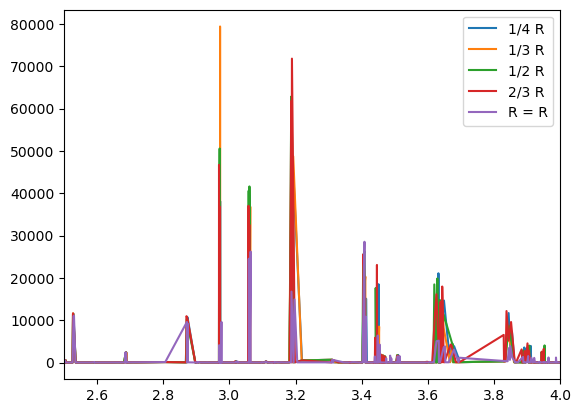

In [7]:
plt.plot(quarter_R['Frequency (GHz)'], quarter_R['Quality factor (1)'], label = '1/4 R')
plt.plot(third_R['Frequency (GHz)'], third_R['Quality factor (1)'], label = '1/3 R')
plt.plot(half_R['Frequency (GHz)'], half_R['Quality factor (1)'], label = '1/2 R')
plt.plot(twothirds_R['Frequency (GHz)'], twothirds_R['Quality factor (1)'], label = '2/3 R')
plt.plot(full_R['Frequency (GHz)'], full_R['Quality factor (1)'], label = 'R = R')
plt.legend()

plt.xlim(2.5, 4.0)

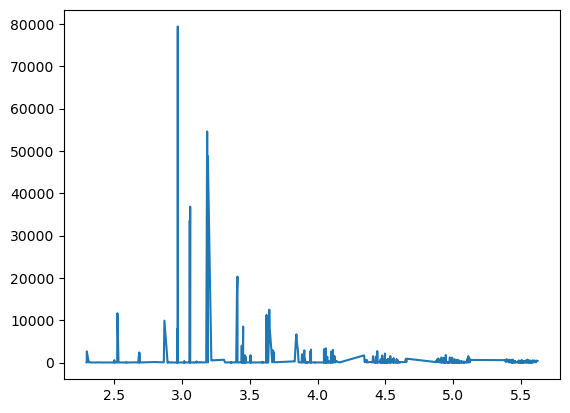

In [8]:
plt.plot(third_R['Frequency (GHz)'], third_R['Quality factor (1)'], label = 'R = R')

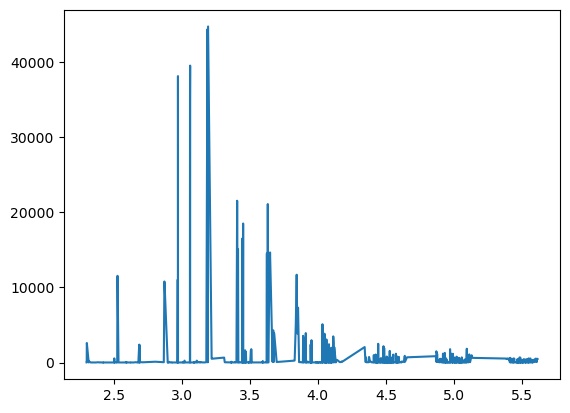

In [9]:
plt.plot(quarter_R['Frequency (GHz)'], quarter_R['Quality factor (1)'], label = '1/4 R')

In [17]:

def find_plot_Q_peaks(Q_freq_data, n_peaks):
    # clean up work for TE doubles in Q1to5
    Q_freq_data['Freq rounded'] = Q_freq_data['Frequency (GHz)'].round(6)
    # Step 3: Drop duplicates, keeping the first occurrence
    Qfac_all = Q_freq_data.drop_duplicates(subset='Freq rounded', keep='first')
    Q_peaks, _ = spg.find_peaks(Qfac_all['Quality factor (1)'])
    Q_peak_freqs = Qfac_all['Frequency (GHz)'].iloc[Q_peaks]
    Q_peak_Qs = Qfac_all['Quality factor (1)'].iloc[Q_peaks]
    #Q_cfs = Qfac_all['% search_freq (Hz)'].iloc[Q_peaks]
    peak_dict = {'freqs': Q_peak_freqs, 'Q': Q_peak_Qs} #'cf': Q_cfs, 
    peaks = pd.DataFrame(peak_dict).sort_values('Q', ascending=False).reset_index(inplace=False)
    top_peaks = peaks.iloc[0:n_peaks]

    plt.figure(figsize = (15,10))
    # plot with peaks labeled
    plt.plot(Qfac_all['Frequency (GHz)'], Qfac_all['Quality factor (1)'])
    plt.xlabel('Freq (GHz)')
    plt.ylabel('Q factor')
    plt.title('Q Factor vs. Eigenfrequency')

    for i in range(len(top_peaks)):
        plt.scatter(top_peaks['freqs'].loc[i], top_peaks['Q'].loc[i], 
                    label = f'({top_peaks["freqs"][i]} GHz, {top_peaks["Q"][i]})')
    plt.legend()

    return Qfac_all, top_peaks

/var/folders/ky/hnfmqvvd74x03rjxm1q6hf580000gn/T/ipykernel_29292/1269091288.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Q_freq_data['Freq rounded'] = Q_freq_data['Frequency (GHz)'].round(6)


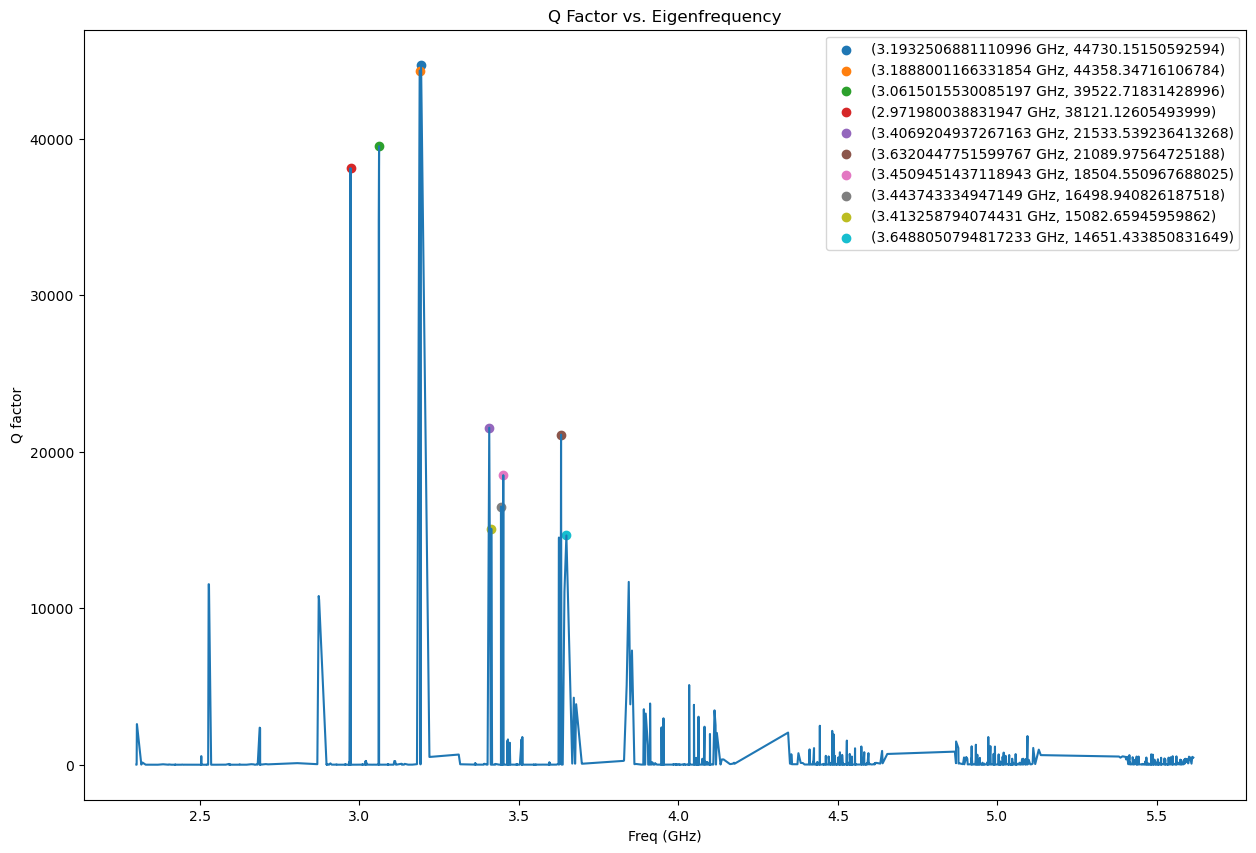

In [18]:
Qfac, peaks = find_plot_Q_peaks(quarter_R, n_peaks=10)

/var/folders/ky/hnfmqvvd74x03rjxm1q6hf580000gn/T/ipykernel_29292/1269091288.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Q_freq_data['Freq rounded'] = Q_freq_data['Frequency (GHz)'].round(6)


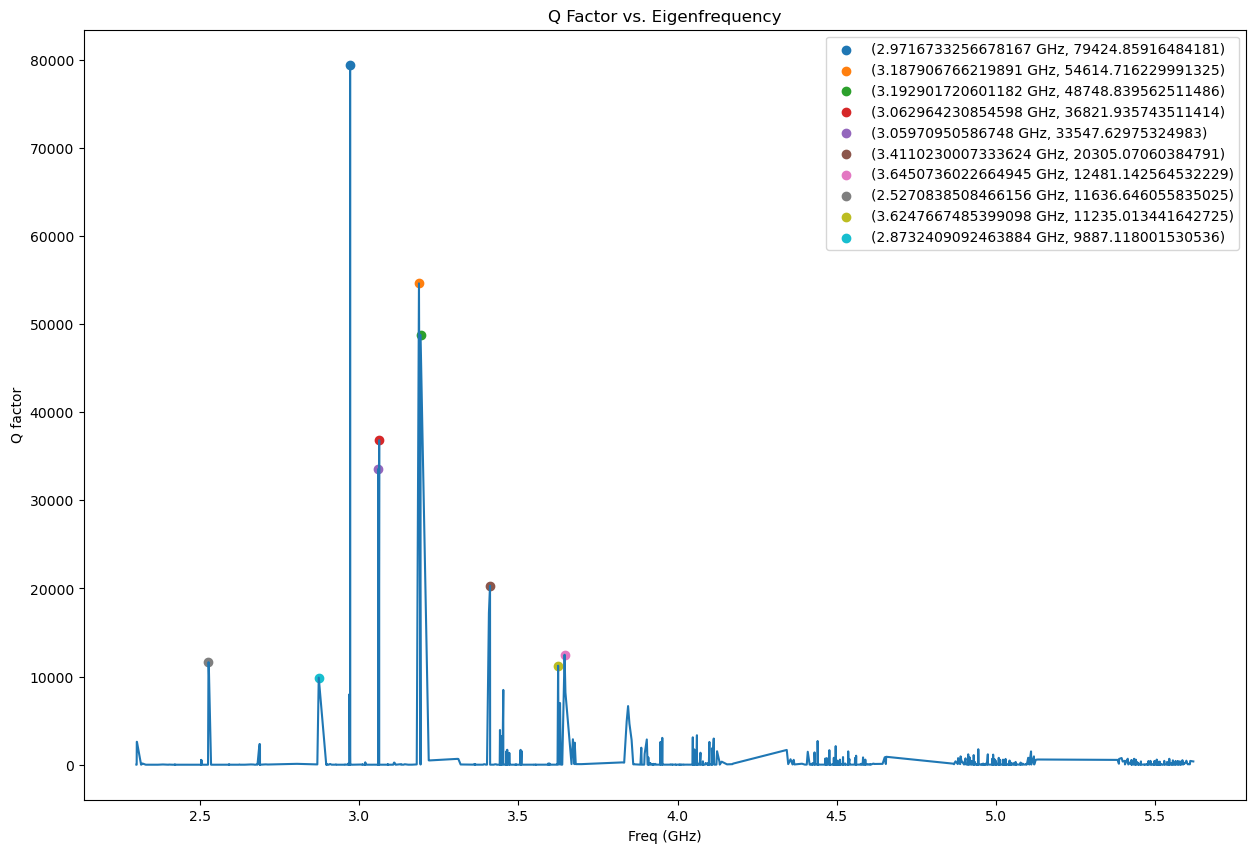

In [19]:
Qfac, peaks = find_plot_Q_peaks(third_R, n_peaks=10)